### Algorithms

In [29]:
INF = float('inf')

In [30]:
def dijkstra_mat(graph, start_value):
    V = len(graph)
    # 1. Initialization (Assuming start_value is the index of the start node)
    dist = [INF for i in range(V)]
    pi = [None for i in range(V)]
    finished = set()
    
    dist[start_value] = 0 # Distance from source to itself is 0

    while (len(finished) < V):
        min_dist = INF
        u = -1 
        
        for i in range(V):
            if i not in finished and dist[i] < min_dist:
                min_dist = dist[i]
                u = i

        if u == -1:
            break
            
        finished.add(u)

        for v in range(V):
            weight = graph[u][v]
            if weight > 0 and v not in finished:
                if dist[u] + weight < dist[v]:
                    dist[v] = dist[u] + weight
                    pi[v] = u 

    return dist, pi

In [31]:
class Heap():

    def __init__(self):
        self.array = []
        self.size = 0
        self.pos = []

    def newMinHeapNode(self, v, dist):
        minHeapNode = [v, dist]
        return minHeapNode

    def swapMinHeapNode(self, a, b):
        t = self.array[a]
        self.array[a] = self.array[b]
        self.array[b] = t

    def minHeapify(self, idx):
        smallest = idx
        left = 2*idx + 1
        right = 2*idx + 2

        if (left < self.size and
           self.array[left][1]
            < self.array[smallest][1]):
            smallest = left

        if (right < self.size and
           self.array[right][1]
            < self.array[smallest][1]):
            smallest = right

        # The nodes to be swapped in min
        # heap if idx is not smallest
        if smallest != idx:

            # Swap positions
            self.pos[self.array[smallest][0]] = idx
            self.pos[self.array[idx][0]] = smallest

            # Swap nodes
            self.swapMinHeapNode(smallest, idx)

            self.minHeapify(smallest)

    # Standard function to extract minimum
    # node from heap
    def extractMin(self):

        # Return NULL wif heap is empty
        if self.isEmpty():
            return

        # Store the root node
        root = self.array[0]

        # Replace root node with last node
        lastNode = self.array[self.size - 1]
        self.array[0] = lastNode

        # Update position of last node
        self.pos[lastNode[0]] = 0
        self.pos[root[0]] = self.size - 1

        # Reduce heap size and heapify root
        self.size -= 1
        self.minHeapify(0)

        return root

    def isEmpty(self):
        return True if self.size == 0 else False

    def decreaseKey(self, v, dist):

        # Get the index of v in  heap array

        i = self.pos[v]

        # Get the node and update its dist value
        self.array[i][1] = dist

        # Travel up while the complete tree is
        # not heapified. This is a O(Logn) loop
        while (i > 0 and self.array[i][1] <
                  self.array[(i - 1) // 2][1]):

            # Swap this node with its parent
            self.pos[ self.array[i][0] ] = (i-1)//2
            self.pos[ self.array[(i-1)//2][0] ] = i
            self.swapMinHeapNode(i, (i - 1)//2 )

            # move to parent index
            i = (i - 1) // 2

    # A utility function to check if a given 
    # vertex 'v' is in min heap or not
    def isInMinHeap(self, v):

        if self.pos[v] < self.size:
            return True
        return False


def printArr(dist, n):
    print ("Vertex\tDistance from source")
    for i in range(n):
        print ("%d\t\t%d" % (i,dist[i]))

def dijkstra_list(adj_list, src):

        V = len(adj_list.keys())
        dist = []   # dist values used to pick minimum 
                    # weight edge in cut

        # minHeap represents set E
        minHeap = Heap()

        #  Initialize min heap with all vertices. 
        # dist value of all vertices
        for v in range(V):
            dist.append(INF)
            minHeap.array.append(minHeap.newMinHeapNode(v, dist[v]))
            minHeap.pos.append(v)

        minHeap.pos[src] = src
        dist[src] = 0
        minHeap.decreaseKey(src, dist[src])

        # Initially size of min heap is equal to V
        minHeap.size = V
        while not minHeap.isEmpty():
            newHeapNode = minHeap.extractMin()
            u = newHeapNode[0]
            for vert, weight in adj_list[u]:
                if (minHeap.isInMinHeap(vert) and weight + dist[u] < dist[vert]):
                        dist[vert] = weight + dist[u]
                        minHeap.decreaseKey(vert, dist[vert])
        return dist

### Graph Generation

In [ ]:
import networkx as nx
import random
import numpy as np

#Generate graph of fixed V
def generate_vary_graph_nx(V, E, max_weight=10):
    G = nx.gnm_random_graph(V, E, directed=True, seed=42)
    
    # Assign random weights to edges
    for (u, v) in G.edges():
        G[u][v]['weight'] = random.randint(1, max_weight)
    
    return G



In [33]:
def graph_to_formats(G):
    adj_matrix = nx.adjacency_matrix(G, weight='weight').todense()
    
    adj_list_dict = {}
    for node in sorted(G.nodes()):
        neighbors_data = G.adj[node]
        adj_list_entry = []
        for neighbor, data in neighbors_data.items():
            adj_list_entry.append((neighbor, data.get('weight', 1))) # Use weight, default to 1 if unweighted

        adj_list_dict[node] = adj_list_entry

    return adj_matrix, adj_list_dict

In [34]:
graph = generate_vary_graph_nx(6, 12)
for (u, v, w) in graph.edges(data='weight'):
    print(f"{u} -> {v}, weight = {w}")

0 -> 5, weight = 10
0 -> 1, weight = 1
1 -> 4, weight = 7
2 -> 1, weight = 6
2 -> 0, weight = 7
3 -> 1, weight = 7
3 -> 4, weight = 10
4 -> 0, weight = 3
4 -> 3, weight = 1
4 -> 1, weight = 7
5 -> 0, weight = 6
5 -> 4, weight = 6


In [35]:
mat, lst = graph_to_formats(graph)
print(mat)
print(lst)
dist, pi = dijkstra_mat(mat, 0)
print(dist)
print(pi)
print(dijkstra_list(lst, 0))

[[ 0  1  0  0  0 10]
 [ 0  0  0  0  7  0]
 [ 7  6  0  0  0  0]
 [ 0  7  0  0 10  0]
 [ 3  7  0  1  0  0]
 [ 6  0  0  0  6  0]]
{0: [(5, 10), (1, 1)], 1: [(4, 7)], 2: [(1, 6), (0, 7)], 3: [(1, 7), (4, 10)], 4: [(0, 3), (3, 1), (1, 7)], 5: [(0, 6), (4, 6)]}
[0, np.int64(1), inf, np.int64(9), np.int64(8), np.int64(10)]
[None, 0, None, 4, 1, 0]
[0, 1, inf, 9, 8, 10]


### Data generation

### Vary V, E = 5000

In [38]:
import time
E = 5000
V_list = list(range(100, 5001, 100))
V_dij_mat_time = []
V_dij_list_time = []
for V in V_list:
    print(f"Processing: {V}")
    V_graph = generate_vary_graph_nx(V, E)
    V_mat, V_lst = graph_to_formats(V_graph)
    start_V_mat_time = time.time()
    dijkstra_mat(V_mat, 0)
    V_dij_mat_time.append(time.time() - start_V_mat_time)

    start_V_list_time = time.time()
    dijkstra_list(V_lst, 0)
    V_dij_list_time.append(time.time() - start_V_list_time)


print("Matrix times:", V_dij_mat_time)
print("List times:", V_dij_list_time)  
    

Processing: 100
Processing: 200
Processing: 300
Processing: 400
Processing: 500
Processing: 600
Processing: 700
Processing: 800
Processing: 900
Processing: 1000
Processing: 1100
Processing: 1200
Processing: 1300
Processing: 1400
Processing: 1500
Processing: 1600
Processing: 1700
Processing: 1800
Processing: 1900
Processing: 2000
Processing: 2100
Processing: 2200
Processing: 2300
Processing: 2400
Processing: 2500
Processing: 2600
Processing: 2700
Processing: 2800
Processing: 2900
Processing: 3000
Processing: 3100
Processing: 3200
Processing: 3300
Processing: 3400
Processing: 3500
Processing: 3600
Processing: 3700
Processing: 3800
Processing: 3900
Processing: 4000
Processing: 4100
Processing: 4200
Processing: 4300
Processing: 4400
Processing: 4500
Processing: 4600
Processing: 4700
Processing: 4800
Processing: 4900
Processing: 5000
Matrix times: [0.007021427154541016, 0.051378726959228516, 0.023332834243774414, 0.07391810417175293, 0.11830687522888184, 0.22574067115783691, 0.3071200847625

Matrix

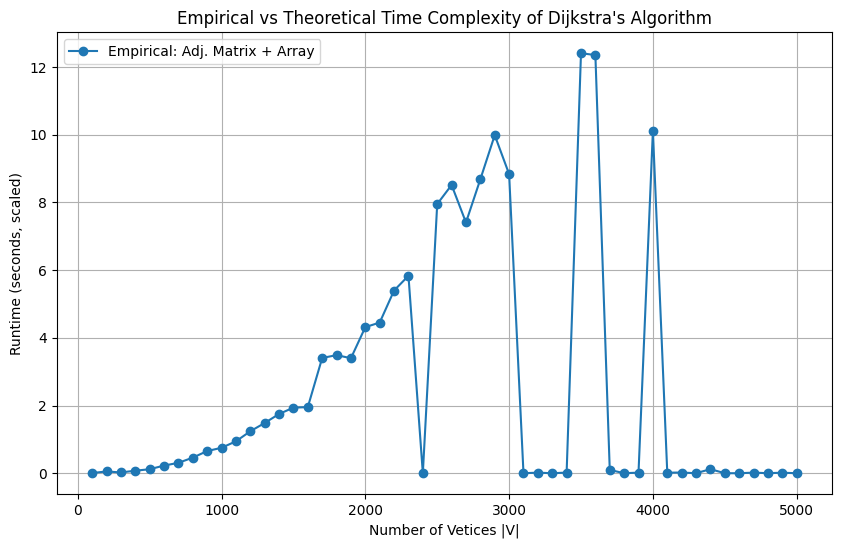

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))

plt.scatter(V_list, V_dij_mat_time, marker='o', label="Empirical: Adj. Matrix + Array")

plt.xlabel("Number of Vetices |V|")
plt.ylabel("Runtime (seconds, scaled)")
plt.title("Empirical vs Theoretical Time Complexity of Dijkstra's Algorithm")
plt.legend()
plt.grid(True)
plt.show()

List

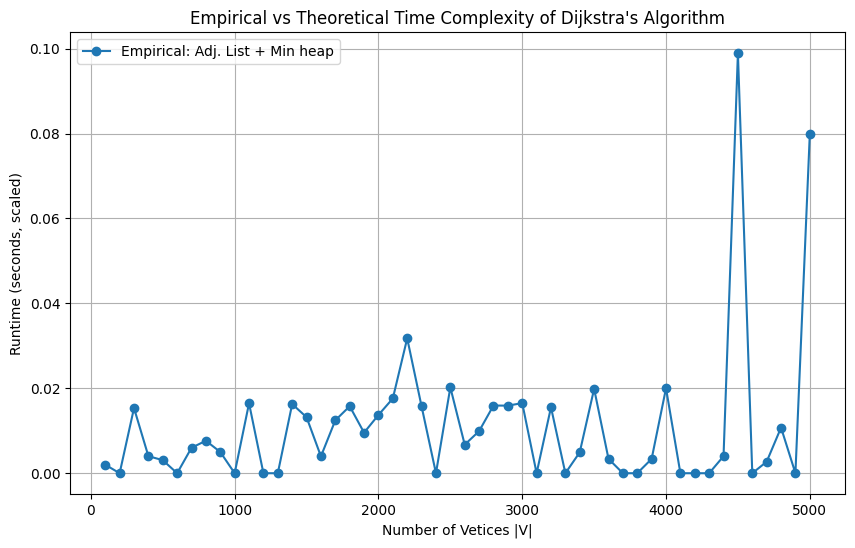

In [40]:
plt.figure(figsize=(10,6))

plt.plot(V_list, V_dij_list_time, marker='o', label="Empirical: Adj. List + Min heap")

plt.xlabel("Number of Vetices |V|")
plt.ylabel("Runtime (seconds, scaled)")
plt.title("Empirical vs Theoretical Time Complexity of Dijkstra's Algorithm")
plt.legend()
plt.grid(True)
plt.show()

### Vary E Fixed V

In [73]:
### Custom list code ###
import heapq
def dijkstra_list(adj_list, start):
    V = len(adj_list)
    dist = [float('inf')] * V
    dist[start] = 0
    pq = [(0, start)]
    
    while pq:
        d, u = heapq.heappop(pq)
        if d > dist[u]:
            continue
        for v, w in adj_list[u]:
            if dist[u] + w < dist[v]:
                dist[v] = dist[u] + w
                heapq.heappush(pq, (dist[v], v))
    return dist

In [92]:
V = 1000
E_list = list(range(0, 100000, 1000))
E_dij_mat_time = []
E_dij_list_time = []
E_enforcement_list = []
enforced_dij_list_time = []
for E in E_list:
    print(f"Processing: {E}")
    E_graph = generate_vary_graph_nx(V, E)
    E_mat, E_lst = graph_to_formats(E_graph)
    start_E_mat_time = time.perf_counter_ns()
    dijkstra_mat(E_mat, 0)
    E_dij_mat_time.append(time.perf_counter_ns() - start_E_mat_time)

    start_E_list_time = time.perf_counter_ns()
    dijkstra_list(V_lst, 0)
    end_time = time.perf_counter_ns() - start_E_list_time
    if end_time < 20:
        E_enforcement_list.append(E)
        enforced_dij_list_time.append(time.perf_counter_ns() - start_E_list_time)
    E_dij_list_time.append(time.perf_counter_ns() - start_E_list_time)

print("Matrix times:", E_dij_mat_time)
print("List times:", E_dij_list_time)  

Processing: 0
Processing: 1000
Processing: 2000
Processing: 3000
Processing: 4000
Processing: 5000
Processing: 6000
Processing: 7000
Processing: 8000
Processing: 9000
Processing: 10000
Processing: 11000
Processing: 12000
Processing: 13000
Processing: 14000
Processing: 15000
Processing: 16000
Processing: 17000
Processing: 18000
Processing: 19000
Processing: 20000
Processing: 21000
Processing: 22000
Processing: 23000
Processing: 24000
Processing: 25000
Processing: 26000
Processing: 27000
Processing: 28000
Processing: 29000
Processing: 30000
Processing: 31000
Processing: 32000
Processing: 33000
Processing: 34000
Processing: 35000
Processing: 36000
Processing: 37000
Processing: 38000
Processing: 39000
Processing: 40000
Processing: 41000
Processing: 42000
Processing: 43000
Processing: 44000
Processing: 45000
Processing: 46000
Processing: 47000
Processing: 48000
Processing: 49000
Processing: 50000
Processing: 51000
Processing: 52000
Processing: 53000
Processing: 54000
Processing: 55000
Proce

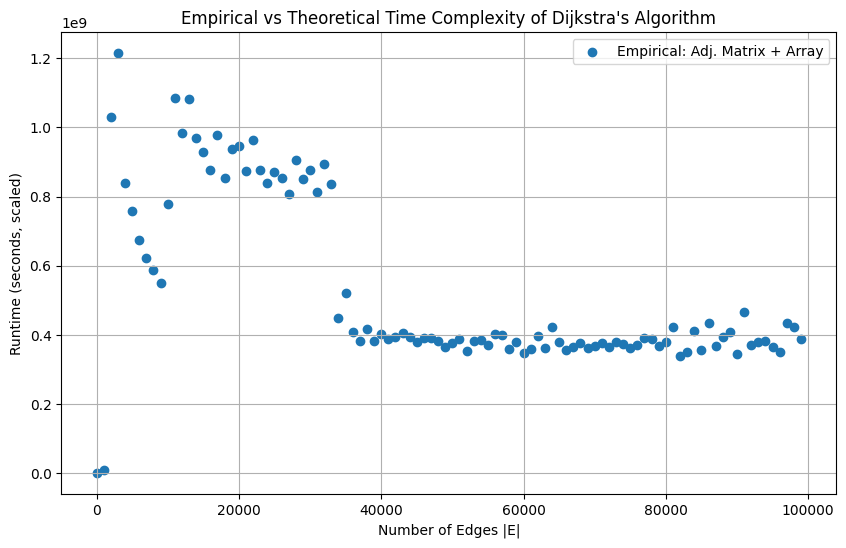

In [93]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))

plt.scatter(E_list, E_dij_mat_time, marker='o', label="Empirical: Adj. Matrix + Array")

plt.xlabel("Number of Edges |E|")
plt.ylabel("Runtime (seconds, scaled)")
plt.title("Empirical vs Theoretical Time Complexity of Dijkstra's Algorithm")
plt.legend()
plt.grid(True)
plt.show()

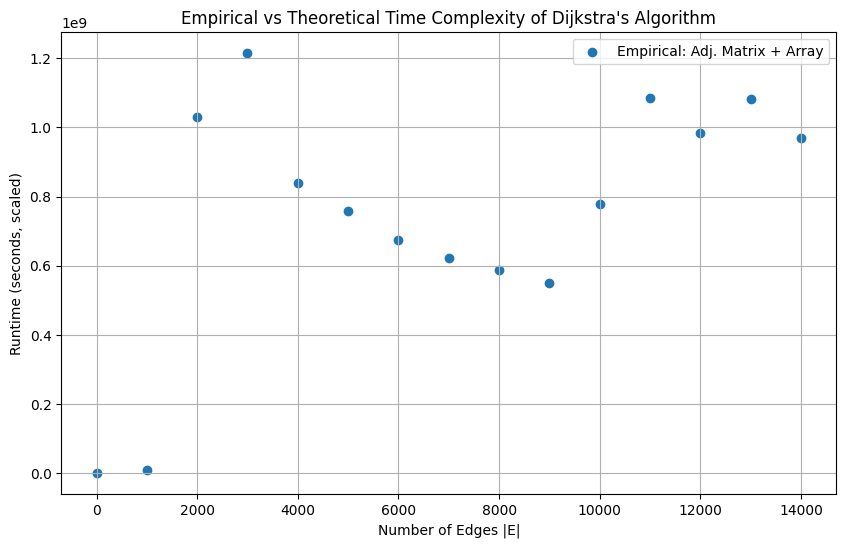

In [94]:
plt.figure(figsize=(10,6))

plt.scatter(E_list[:15], E_dij_mat_time[:15], marker='o', label="Empirical: Adj. Matrix + Array")

plt.xlabel("Number of Edges |E|")
plt.ylabel("Runtime (seconds, scaled)")
plt.title("Empirical vs Theoretical Time Complexity of Dijkstra's Algorithm")
plt.legend()
plt.grid(True)
plt.show()

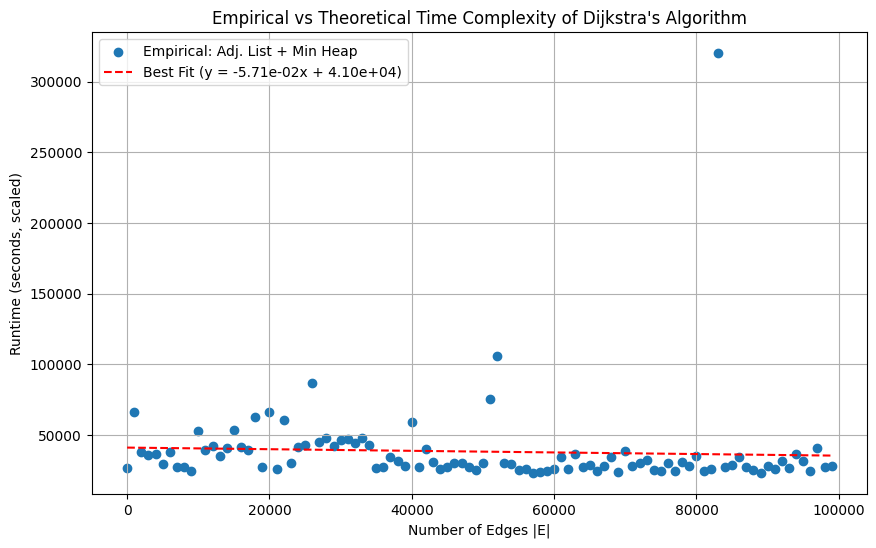

In [95]:
import numpy as np
import matplotlib.pyplot as plt

# Example data
# E_list = [...]
# E_dij_list_time = [...]

plt.figure(figsize=(10,6))
plt.scatter(E_list, E_dij_list_time, marker='o', label="Empirical: Adj. List + Min Heap")

# --- Best-fit line ---
coeffs = np.polyfit(E_list, E_dij_list_time, 1)  # degree 1 = linear
poly_eq = np.poly1d(coeffs)
best_fit_y = poly_eq(E_list)

plt.plot(E_list, best_fit_y, color='red', linestyle='--', label=f"Best Fit (y = {coeffs[0]:.2e}x + {coeffs[1]:.2e})")

# --- Labels & styling ---
plt.xlabel("Number of Edges |E|")
plt.ylabel("Runtime (seconds, scaled)")
plt.title("Empirical vs Theoretical Time Complexity of Dijkstra's Algorithm")
plt.legend()
plt.grid(True)
plt.show()


TypeError: expected non-empty vector for x

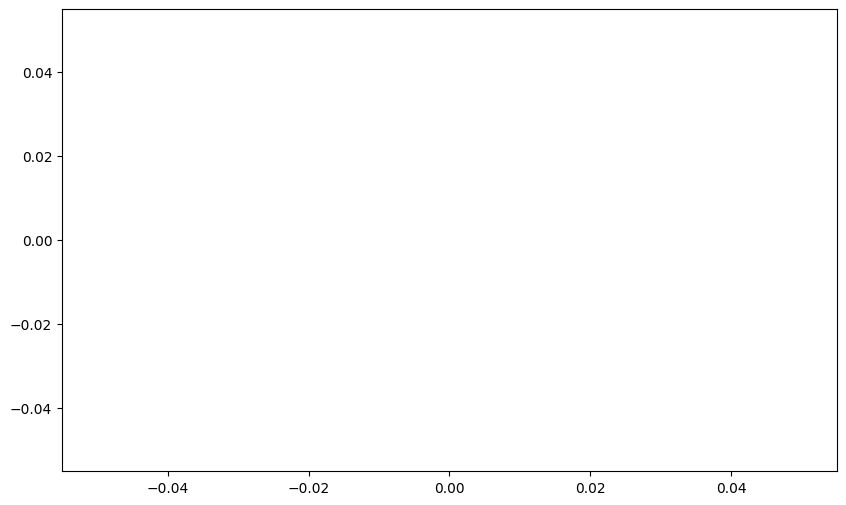

In [96]:
plt.figure(figsize=(10,6))
plt.scatter(E_enforcement_list, enforced_dij_list_time, marker='o', label="Empirical: Adj. List + Min Heap")

# --- Best-fit line ---
coeffs = np.polyfit(E_enforcement_list, enforced_dij_list_time, 1)  # degree 1 = linear
poly_eq = np.poly1d(coeffs)
best_fit_y = poly_eq(E_enforcement_list)

plt.plot(E_enforcement_list, best_fit_y, color='red', linestyle='--', label=f"Best Fit (y = {coeffs[0]:.2e}x + {coeffs[1]:.2e})")

# --- Labels & styling ---
plt.xlabel("Number of Edges |E|")
plt.ylabel("Runtime (seconds, scaled)")
plt.title("Empirical vs Theoretical Time Complexity of Dijkstra's Algorithm")
plt.legend()
plt.grid(True)
plt.show()

### (A)